In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from PIL import Image

sns.set_theme(style='whitegrid', font_scale=1.1)

df = pd.read_csv('data/features/radiate_features.csv')

AU_COLS = [
    'AU01','AU02','AU04','AU05','AU06','AU07','AU09','AU10',
    'AU11','AU12','AU14','AU15','AU17','AU20','AU23','AU24',
    'AU25','AU26','AU28','AU43'
]

df = df[df['race'].isin(['Asian', 'Hispanic'])].copy()

print(df.groupby(['race', 'emotion_label']).size().unstack(fill_value=0))

emotion_label  Anger  Calm  Disgust  Fear  Happy  Neutral  Sad  Surprise
race                                                                    
Asian             48    46       46    46     68       46   45        23
Hispanic          42    42       40    42     60       42   41        20


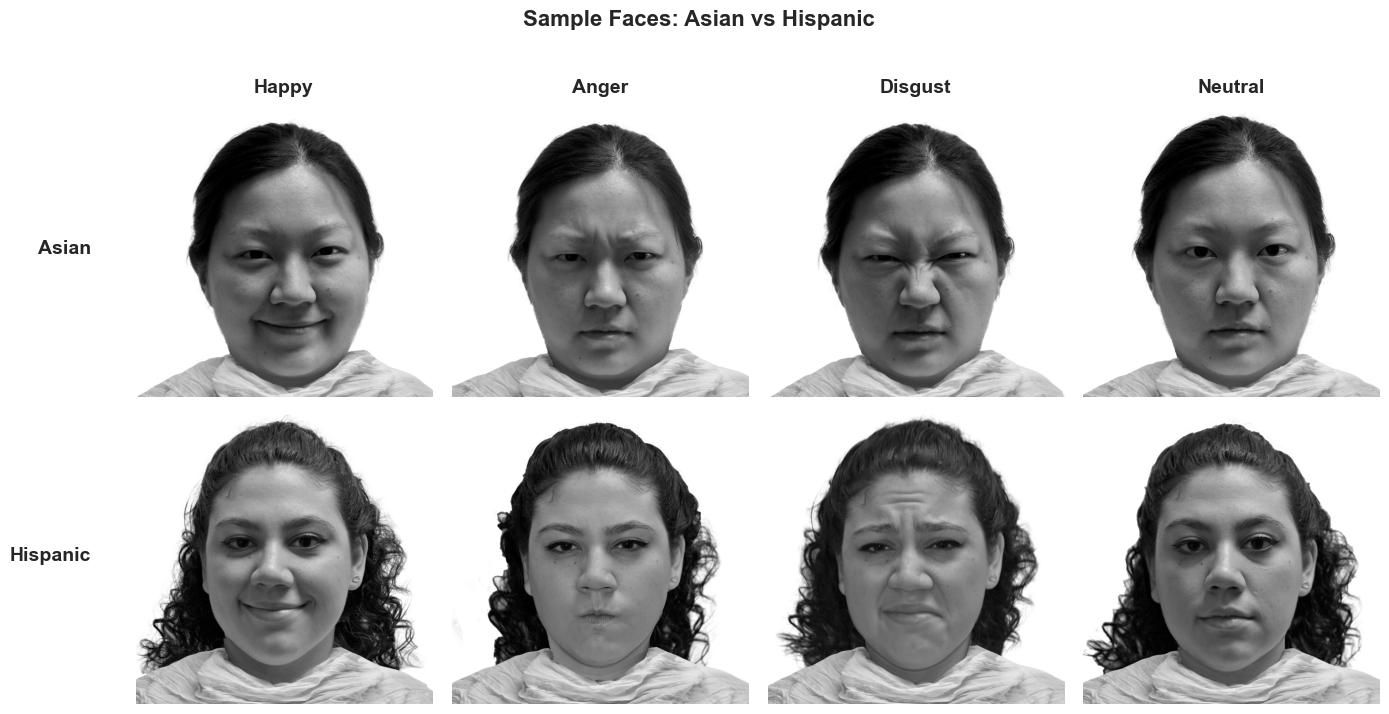

In [2]:
emotions = ['Happy', 'Anger', 'Disgust', 'Neutral']
races = ['Asian', 'Hispanic']

# Pick one representative face per race x emotion (first female model)
sample_faces = {}
for race in races:
    for emo in emotions:
        row = df[(df['race'] == race) & (df['emotion_label'] == emo) & (df['gender'] == 'Female')].iloc[0]
        sample_faces[(race, emo)] = row

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for r, race in enumerate(races):
    for c, emo in enumerate(emotions):
        ax = axes[r, c]
        row = sample_faces[(race, emo)]
        img = Image.open(row['image_path'])
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines[:].set_visible(False)
        if r == 0:
            ax.set_title(emo, fontsize=14, fontweight='bold')
    # Add race label to the left of the first column
    axes[r, 0].text(-0.15, 0.5, race, fontsize=14, fontweight='bold',
                     transform=axes[r, 0].transAxes, va='center', ha='right')

fig.suptitle('Sample Faces: Asian vs Hispanic', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

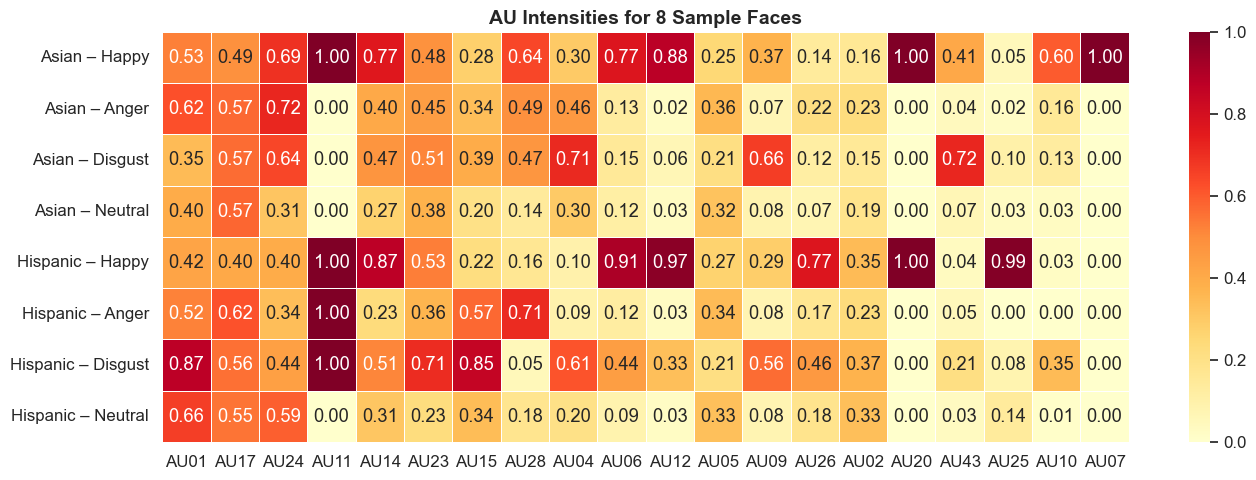

In [3]:
# AU heatmap for the 8 sample faces
rows = []
labels = []
for race in races:
    for emo in emotions:
        row = sample_faces[(race, emo)]
        rows.append(row[AU_COLS].values.astype(float))
        labels.append(f'{race} \u2013 {emo}')

heat_df = pd.DataFrame(rows, columns=AU_COLS, index=labels)

# Sort columns by mean intensity (highest left)
col_order = heat_df.mean().sort_values(ascending=False).index
heat_df = heat_df[col_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('AU Intensities for 8 Sample Faces', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

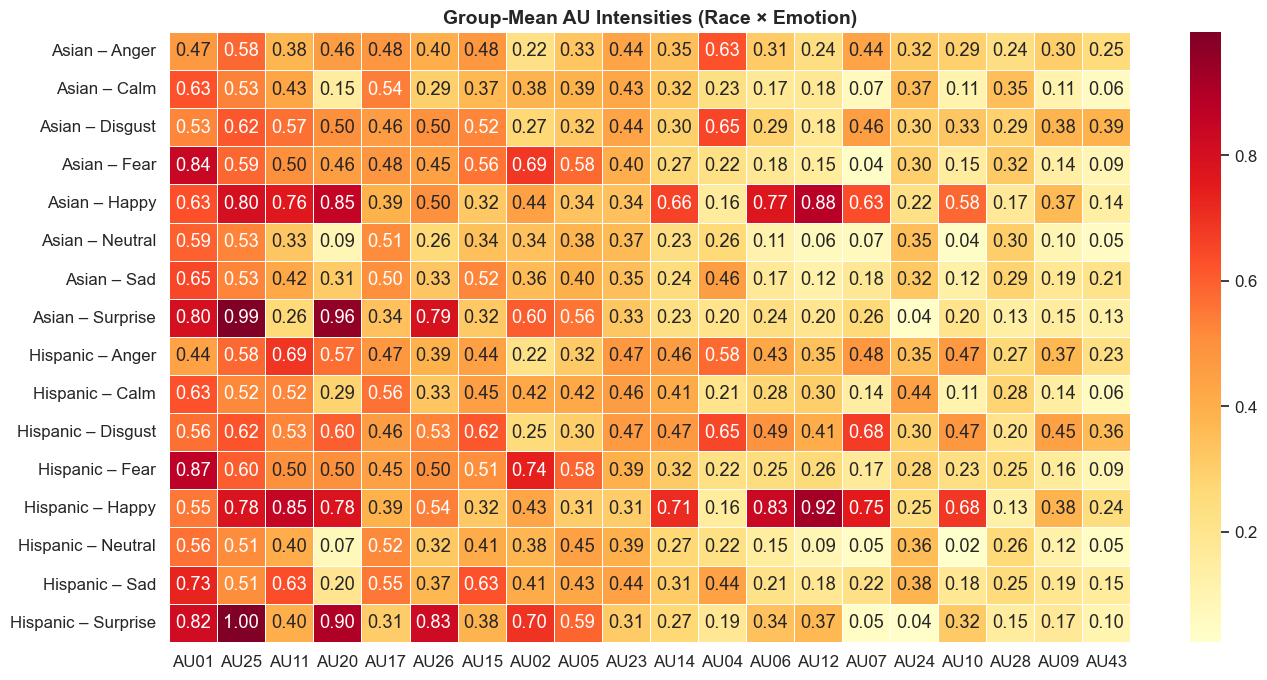

In [4]:
# Group-mean AU heatmap (race x emotion)
group_mean = df.groupby(['race', 'emotion_label'])[AU_COLS].mean()
group_mean.index = [f'{r} \u2013 {e}' for r, e in group_mean.index]

# Sort columns by overall mean
col_order = group_mean.mean().sort_values(ascending=False).index
group_mean = group_mean[col_order]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(group_mean, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Group-Mean AU Intensities (Race \u00d7 Emotion)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

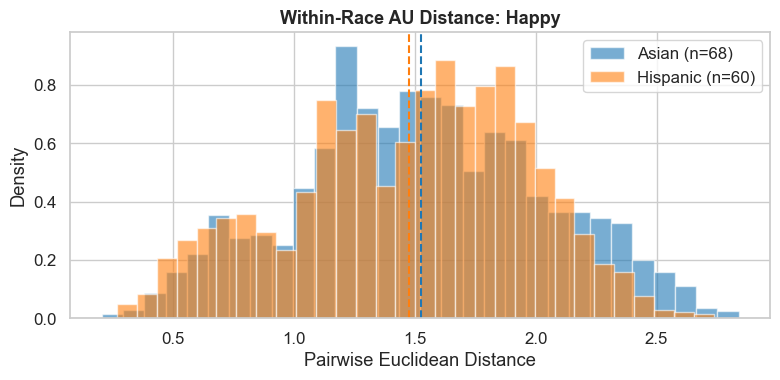

In [5]:
def plot_pairwise_distances(df, emotion, au_cols):
    fig, ax = plt.subplots(figsize=(8, 4))
    for race, color in [('Asian', 'tab:blue'), ('Hispanic', 'tab:orange')]:
        vecs = df[(df['race'] == race) & (df['emotion_label'] == emotion)][au_cols].values
        dists = pdist(vecs, metric='euclidean')
        ax.hist(dists, bins=30, alpha=0.6, color=color, label=f'{race} (n={len(vecs)})', density=True)
        ax.axvline(dists.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_xlabel('Pairwise Euclidean Distance')
    ax.set_ylabel('Density')
    ax.set_title(f'Within-Race AU Distance: {emotion}', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_pairwise_distances(df, 'Happy', AU_COLS)

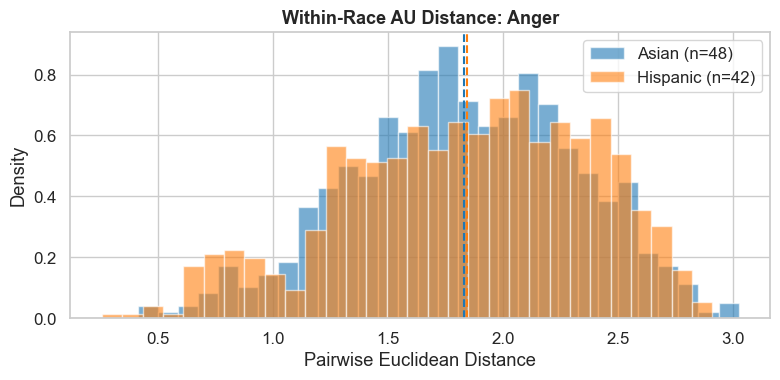

In [6]:
plot_pairwise_distances(df, 'Anger', AU_COLS)

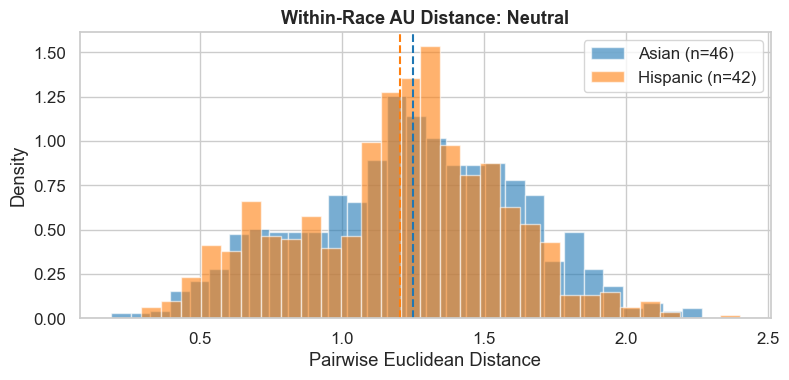

In [7]:
plot_pairwise_distances(df, 'Neutral', AU_COLS)

## Observations

The group-mean heatmap reveals that Asian and Hispanic faces activate similar AUs for the same emotion, but with different magnitudes — e.g., AU12 (lip corner puller) tends to be stronger in Hispanic Happy faces while AU06 (cheek raiser) is more prominent in Asian Happy faces. The pairwise distance distributions show that within-race AU variability is comparable for both groups across emotions, though Hispanic faces occasionally display slightly wider spread, suggesting more heterogeneity in AU expression.